# ViT-B/16 Multilabel UCMerced — Stratified vs Random Split

## Hipótesis
Los modelos ViT pre-entrenados (ImageNet, ~86 M parámetros) son suficientemente robustos al desbalance de clases como para **no** degradarse significativamente cuando el split train/val es aleatorio en lugar de estratificado.
- **H0 (hipótesis verdadera):** Δ métricas entre ambos modelos < 2 pp → el pre-entrenamiento compensa el desbalance.
- **H1 (hipótesis falsa):** Δ métricas ≥ 2 pp → el split estratificado sigue siendo necesario.

Ambos modelos son ViT-B/16 idénticos (misma seed, mismos pesos iniciales), solo difiere el tipo de split de train/val.

## 1. Setup — Drive, dependencias y repo

In [23]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [24]:
# Run this everytime you update something in the repo\!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 342 bytes | 8.00 KiB/s, done.
From https://github.com/gabrielcastrob/Deep_learning_WUR
   ece37f9..fcd5ca6  main       -> origin/main
Updating ece37f9..fcd5ca6
Fast-forward
 utils.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


## 2. Descarga del dataset UCMerced

In [25]:
import zipfile, subprocess, shutil

if not os.path.exists('ucmdata'):
    print("Cloning ucmdata repo and extracting images...")
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')
    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zf:
        zf.extractall('UCMImages')
    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
    os.chdir(PROJECT_DIR)
    print("Dataset ready.")
else:
    print("Dataset already present.")

Dataset already present.


## 3. Importaciones

In [26]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tvm
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Import from utils — reload to pick up any latest changes
import utils
importlib.reload(utils)
from utils import (
    build_dataloaders,
    LightningModuleMultilabel,
    compute_test_metrics,
    append_metrics_to_csv,
    plot_training_curves,
    plot_per_class_metrics,
)

L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
Path("outputs/checkpoints").mkdir(parents=True, exist_ok=True)
Path("outputs/logs").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

/content/drive/MyDrive/DL_Group_MGI1/utils.py:26: SyntaxWarning: invalid escape sequence '\L'
  IMAGE\LABEL   airplane   bare-soil   buildings   …   water
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


## 4. Hiperparámetros

In [27]:
PRETRAINED_MODEL      = "vit_b_16"
MAX_EPOCHS            = 15
EARLYSTOPPING_EPOCHS  = 7
LR                    = 3e-5    # Lower LR recommended for ViT fine-tuning
WEIGHT_DECAY          = 5e-2    # Standard weight decay for ViT (Dosovitskiy et al.)
THRESHOLD             = 0.5
SEED                  = 42
BATCH_SIZE            = 32
NUM_WORKERS           = 2

print(f"Model:        {PRETRAINED_MODEL}")
print(f"Max epochs:   {MAX_EPOCHS}  |  Early stopping: {EARLYSTOPPING_EPOCHS}")
print(f"LR:           {LR}  |  Weight decay: {WEIGHT_DECAY}")
print(f"Batch size:   {BATCH_SIZE}  |  Threshold: {THRESHOLD}")

Model:        vit_b_16
Max epochs:   15  |  Early stopping: 7
LR:           3e-05  |  Weight decay: 0.05
Batch size:   32  |  Threshold: 0.5


## 5. Dataloaders — Modelo A (Stratified) y Modelo B (Random)

Se construyen dos sets de dataloaders con `build_dataloaders()` desde `utils.py`.  
El argumento `stratified` controla el tipo de split:
- `stratified=True` → `MultilabelStratifiedShuffleSplit` (preserva distribución de clases)
- `stratified=False` → shuffle aleatorio con la misma seed

In [28]:
# ── Modelo A: Stratified split ──────────────────────────────────────────────
print("=" * 55)
print("  DATALOADER A — STRATIFIED SPLIT")
print("=" * 55)

train_loader_A, val_loader_A, test_loader_A, classes, pos_w_A = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = True,
)
NUM_CLASSES = len(classes)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_A.dataset)} | Val: {len(val_loader_A.dataset)} | Test: {len(test_loader_A.dataset)}")

  DATALOADER A — STRATIFIED SPLIT
Classes: 17
Train: 1469 | Val: 317 | Test: 314


In [29]:
# ── Modelo B: Random split ───────────────────────────────────────────────────
print("=" * 55)
print("  DATALOADER B — RANDOM SPLIT")
print("=" * 55)

train_loader_B, val_loader_B, test_loader_B, _, pos_w_B = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = False,
)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_B.dataset)} | Val: {len(val_loader_B.dataset)} | Test: {len(test_loader_B.dataset)}")

  DATALOADER B — RANDOM SPLIT
Classes: 17
Train: 1470 | Val: 315 | Test: 315


## 6. Arquitectura ViT-B/16

Se reemplaza únicamente la cabeza de clasificación (`model.heads.head`) por una capa `Linear(768 → 17)`.  
Todos los pesos del transformer permanecen entrenables (fine-tuning completo).

In [30]:
def build_vit_b16(num_classes: int):
    """ViT-B/16 pre-trained on ImageNet1K with new multilabel classification head."""
    weights = tvm.ViT_B_16_Weights.IMAGENET1K_V1
    model   = tvm.vit_b_16(weights=weights)
    in_feat = model.heads.head.in_features   # 768
    model.heads.head = nn.Linear(in_feat, num_classes)
    return model

# Quick check
_tmp = build_vit_b16(NUM_CLASSES)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"ViT-B/16  |  Trainable params: {n_params:,}  |  Output logits: {NUM_CLASSES}")
del _tmp

ViT-B/16  |  Trainable params: 85,811,729  |  Output logits: 17


## 7. Entrenamiento — Modelo A (Stratified Split)

In [31]:
print("=" * 55)
print("  MODELO A — STRATIFIED SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)

backbone_A = build_vit_b16(NUM_CLASSES)
lit_A = LightningModuleMultilabel(
    model        = backbone_A,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_A,
)

ckpt_A = ModelCheckpoint(
    dirpath   = "outputs/checkpoints",
    filename  = "vitA_stratified-best-{epoch:02d}-{val_f1:.4f}",
    monitor   = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_A = EarlyStopping(
    monitor   = "val_f1", mode="max",
    patience  = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_A = CSVLogger("outputs/logs", name="vitA_stratified")

trainer_A = L.Trainer(
    max_epochs      = MAX_EPOCHS,
    accelerator     = "auto",
    devices         = "auto",
    callbacks       = [ckpt_A, early_A],
    logger          = logger_A,
    log_every_n_steps = 5,
)
trainer_A.fit(lit_A, train_loader_A, val_loader_A)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO A — STRATIFIED SPLIT


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.940
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.940


INFO: Metric val_f1 improved by 0.001 >= min_delta = 0.001. New best score: 0.941
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.001 >= min_delta = 0.001. New best score: 0.941


INFO: Metric val_f1 improved by 0.009 >= min_delta = 0.001. New best score: 0.950
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.009 >= min_delta = 0.001. New best score: 0.950


INFO: Metric val_f1 improved by 0.001 >= min_delta = 0.001. New best score: 0.951
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.001 >= min_delta = 0.001. New best score: 0.951


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


## 8. Entrenamiento — Modelo B (Random Split)

In [32]:
print("=" * 55)
print("  MODELO B — RANDOM SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)   # misma seed → misma inicialización de pesos

backbone_B = build_vit_b16(NUM_CLASSES)
lit_B = LightningModuleMultilabel(
    model        = backbone_B,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_B,
)

ckpt_B = ModelCheckpoint(
    dirpath   = "outputs/checkpoints",
    filename  = "vitB_random-best-{epoch:02d}-{val_f1:.4f}",
    monitor   = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_B = EarlyStopping(
    monitor   = "val_f1", mode="max",
    patience  = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_B = CSVLogger("outputs/logs", name="vitB_random")

trainer_B = L.Trainer(
    max_epochs      = MAX_EPOCHS,
    accelerator     = "auto",
    devices         = "auto",
    callbacks       = [ckpt_B, early_B],
    logger          = logger_B,
    log_every_n_steps = 5,
)
trainer_B.fit(lit_B, train_loader_B, val_loader_B)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO B — RANDOM SPLIT


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.943
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.011 >= min_delta = 0.001. New best score: 0.943


INFO: Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.945
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.945


INFO: Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.947
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.947


INFO: Metric val_f1 improved by 0.005 >= min_delta = 0.001. New best score: 0.952
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.005 >= min_delta = 0.001. New best score: 0.952


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


## 9. Evaluación en test — Modelo A (Stratified)

In [33]:
print("=" * 55)
print("  EVALUACIÓN MODELO A — STRATIFIED SPLIT")
print("=" * 55)

trainer_A.test(lit_A, dataloaders=test_loader_A, ckpt_path="best")

best_path_A = ckpt_A.best_model_path
print(f"Best checkpoint: {best_path_A}")
lit_A = LightningModuleMultilabel.load_from_checkpoint(best_path_A, model=lit_A.model)

preds_out_A = trainer_A.predict(lit_A, dataloaders=test_loader_A)
probs_A  = torch.cat([b["probs"]  for b in preds_out_A]).numpy()
preds_A  = torch.cat([b["preds"]  for b in preds_out_A]).numpy()
labels_A = torch.cat([b["labels"] for b in preds_out_A]).numpy()

metrics_A = compute_test_metrics(preds_A, labels_A, probs_A)
print("\nModel A (Stratified) — Test Metrics:")
for k, v in metrics_A.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_A, model_name="ViT_B16_Stratified")

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=11-val_f1=0.9511.ckpt


  EVALUACIÓN MODELO A — STRATIFIED SPLIT


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=11-val_f1=0.9511.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9610340595245361     │
│          test_f1          │     0.942171573638916     │
│         test_loss         │    0.15930283069610596    │
│         test_map          │    0.9817811250686646     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=11-val_f1=0.9511.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model A (Stratified) — Test Metrics:
  accuracy       : 0.9610
  macro_f1       : 0.9422
  micro_f1       : 0.9037
  samples_f1     : 0.9079
  macro_map      : 0.9818
  hamming_loss   : 0.0390
  subset_acc     : 0.5318


## 10. Evaluación en test — Modelo B (Random)

In [34]:
print("=" * 55)
print("  EVALUACIÓN MODELO B — RANDOM SPLIT")
print("=" * 55)

trainer_B.test(lit_B, dataloaders=test_loader_B, ckpt_path="best")

best_path_B = ckpt_B.best_model_path
print(f"Best checkpoint: {best_path_B}")
lit_B = LightningModuleMultilabel.load_from_checkpoint(best_path_B, model=lit_B.model)

preds_out_B = trainer_B.predict(lit_B, dataloaders=test_loader_B)
probs_B  = torch.cat([b["probs"]  for b in preds_out_B]).numpy()
preds_B  = torch.cat([b["preds"]  for b in preds_out_B]).numpy()
labels_B = torch.cat([b["labels"] for b in preds_out_B]).numpy()

metrics_B = compute_test_metrics(preds_B, labels_B, probs_B)
print("\nModel B (Random) — Test Metrics:")
for k, v in metrics_B.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_B, model_name="ViT_B16_Random")

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=09-val_f1=0.9518.ckpt


  EVALUACIÓN MODELO B — RANDOM SPLIT


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=09-val_f1=0.9518.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9622782468795776     │
│          test_f1          │       0.9443359375        │
│         test_loss         │    0.1732868254184723     │
│         test_map          │     0.980508029460907     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=09-val_f1=0.9518.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model B (Random) — Test Metrics:
  accuracy       : 0.9623
  macro_f1       : 0.9443
  micro_f1       : 0.9080
  samples_f1     : 0.9196
  macro_map      : 0.9805
  hamming_loss   : 0.0377
  subset_acc     : 0.5587


## 11. Tabla comparativa y veredicto de hipótesis

In [35]:
comparison_df = pd.DataFrame({
    "Metric":     list(metrics_A.keys()),
    "Stratified": [round(v, 4) for v in metrics_A.values()],
    "Random":     [round(v, 4) for v in metrics_B.values()],
})
comparison_df["Δ (Random − Strat)"] = (
    comparison_df["Random"] - comparison_df["Stratified"]
).round(4)

print("\n" + "=" * 55)
print("  STRATIFIED vs RANDOM — COMPARATIVA FINAL")
print("=" * 55)
print(comparison_df.to_string(index=False))

# ── Hypothesis verdict ────────────────────────────────────────────────────────
delta_f1  = abs(metrics_A["macro_f1"] - metrics_B["macro_f1"])
delta_map = abs(metrics_A["macro_map"] - metrics_B["macro_map"])

print(f"\nΔ macro-F1  = {delta_f1:.4f}")
print(f"Δ macro-mAP = {delta_map:.4f}")

if delta_f1 < 0.02:
    print("\n✓ H0 no rechazada: Δ < 2 pp → el pre-entrenamiento compensa el desbalance.")
else:
    print("\n✗ H1 confirmada: Δ ≥ 2 pp → el split estratificado sigue siendo necesario.")


  STRATIFIED vs RANDOM — COMPARATIVA FINAL
      Metric  Stratified  Random  Δ (Random − Strat)
    accuracy      0.9610  0.9623              0.0013
    macro_f1      0.9422  0.9443              0.0021
    micro_f1      0.9037  0.9080              0.0043
  samples_f1      0.9079  0.9196              0.0117
   macro_map      0.9818  0.9805             -0.0013
hamming_loss      0.0390  0.0377             -0.0013
  subset_acc      0.5318  0.5587              0.0269

Δ macro-F1  = 0.0022
Δ macro-mAP = 0.0013

✓ H0 no rechazada: Δ < 2 pp → el pre-entrenamiento compensa el desbalance.


## 12. Curvas de aprendizaje

Saved training curves to: outputs/figures/vitA_stratified_curves.png


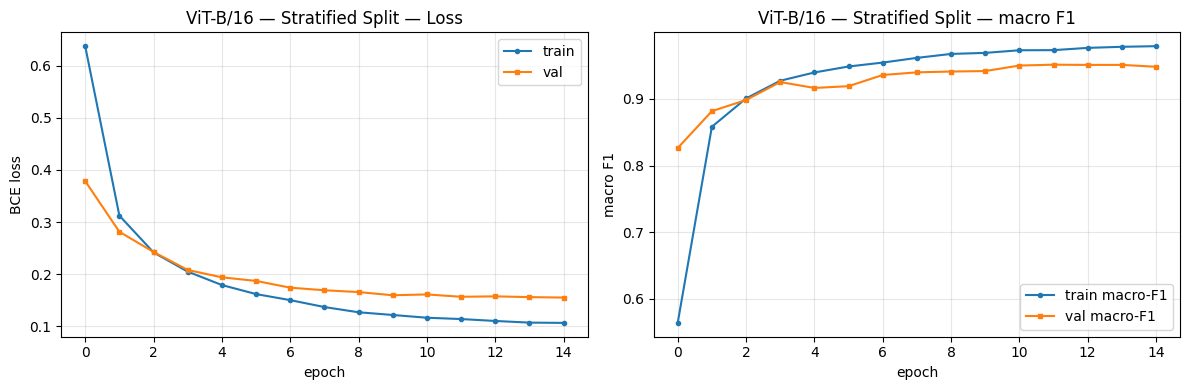

Saved training curves to: outputs/figures/vitB_random_curves.png


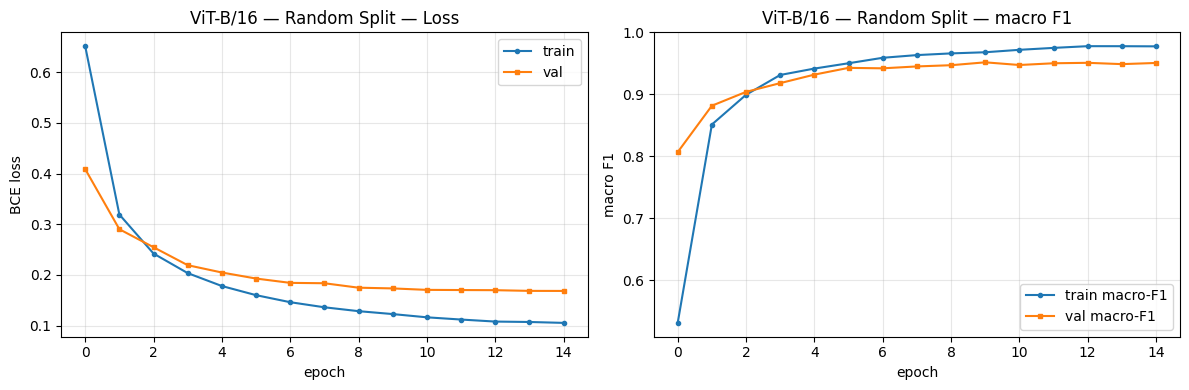

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'ViT-B/16 — Random Split — Loss'}, xlabel='epoch', ylabel='BCE loss'>,
        <Axes: title={'center': 'ViT-B/16 — Random Split — macro F1'}, xlabel='epoch', ylabel='macro F1'>],
       dtype=object))

In [36]:
plot_training_curves(
    logger_A,
    model_name = "ViT-B/16 — Stratified Split",
    save_path  = "outputs/figures/vitA_stratified_curves.png",
)

plot_training_curves(
    logger_B,
    model_name = "ViT-B/16 — Random Split",
    save_path  = "outputs/figures/vitB_random_curves.png",
)

## 13. Métricas per-class — F1 y AP por clase

Saved per-class metrics plot to: outputs/figures/vitA_per_class.png


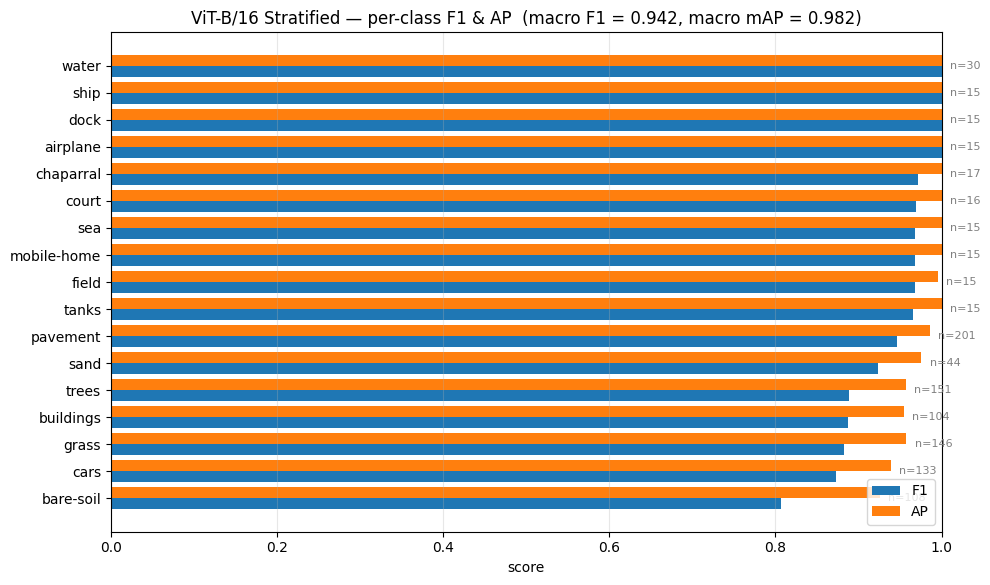


Per-class Summary:
      class  positives     F1     AP
  bare-soil        108 0.8069 0.9257
       cars        133 0.8729 0.9389
      grass        146 0.8828 0.9574
  buildings        104 0.8868 0.9542
      trees        151 0.8889 0.9567
       sand         44 0.9231 0.9757
   pavement        201 0.9458 0.9859
      tanks         15 0.9655 1.0000
      field         15 0.9677 0.9958
mobile-home         15 0.9677 1.0000
        sea         15 0.9677 1.0000
      court         16 0.9697 1.0000
  chaparral         17 0.9714 1.0000
   airplane         15 1.0000 1.0000
       dock         15 1.0000 1.0000
       ship         15 1.0000 1.0000
      water         30 1.0000 1.0000
Saved summary table to: outputs/vitA_per_class.csv
Saved per-class metrics plot to: outputs/figures/vitB_per_class.png


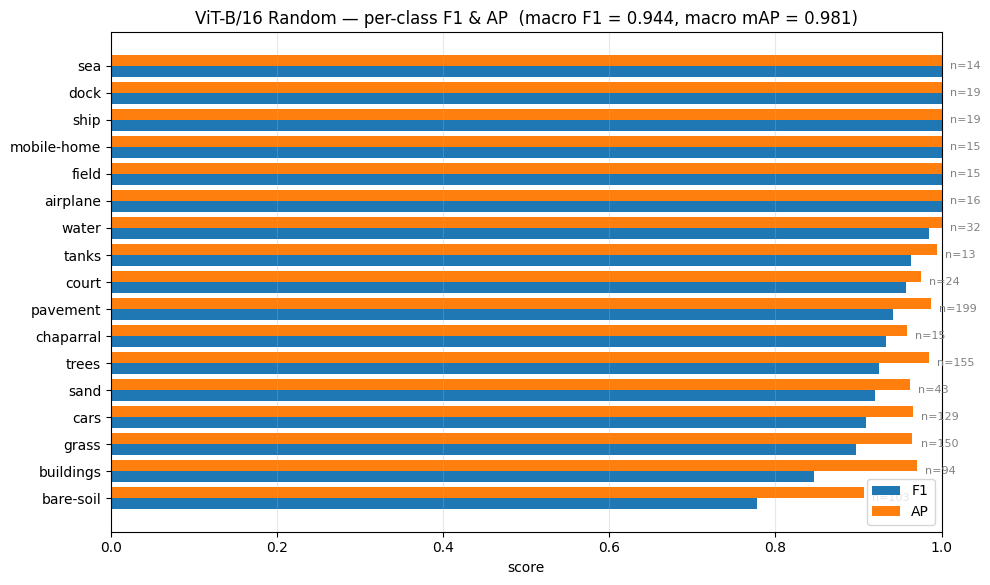


Per-class Summary:
      class  positives     F1     AP
  bare-soil        103 0.7782 0.9068
  buildings         94 0.8462 0.9702
      grass        150 0.8968 0.9648
       cars        129 0.9091 0.9657
       sand         43 0.9195 0.9616
      trees        155 0.9250 0.9850
  chaparral         15 0.9333 0.9583
   pavement        199 0.9415 0.9869
      court         24 0.9565 0.9747
      tanks         13 0.9630 0.9945
      water         32 0.9846 1.0000
   airplane         16 1.0000 1.0000
      field         15 1.0000 1.0000
mobile-home         15 1.0000 1.0000
       ship         19 1.0000 1.0000
       dock         19 1.0000 1.0000
        sea         14 1.0000 1.0000
Saved summary table to: outputs/vitB_per_class.csv


(<Figure size 1000x595 with 1 Axes>,
 <Axes: title={'center': 'ViT-B/16 Random — per-class F1 & AP  (macro F1 = 0.944, macro mAP = 0.981)'}, xlabel='score'>,
           class  positives      F1      AP
 0     bare-soil        103  0.7782  0.9068
 1     buildings         94  0.8462  0.9702
 2         grass        150  0.8968  0.9648
 3          cars        129  0.9091  0.9657
 4          sand         43  0.9195  0.9616
 5         trees        155  0.9250  0.9850
 6     chaparral         15  0.9333  0.9583
 7      pavement        199  0.9415  0.9869
 8         court         24  0.9565  0.9747
 9         tanks         13  0.9630  0.9945
 10        water         32  0.9846  1.0000
 11     airplane         16  1.0000  1.0000
 12        field         15  1.0000  1.0000
 13  mobile-home         15  1.0000  1.0000
 14         ship         19  1.0000  1.0000
 15         dock         19  1.0000  1.0000
 16          sea         14  1.0000  1.0000)

In [37]:
plot_per_class_metrics(
    labels_A, preds_A, probs_A, classes,
    macro_f1   = metrics_A["macro_f1"],
    macro_map  = metrics_A["macro_map"],
    model_name = "ViT-B/16 Stratified",
    save_path  = "outputs/figures/vitA_per_class.png",
    csv_output = "outputs/vitA_per_class.csv",
)

plot_per_class_metrics(
    labels_B, preds_B, probs_B, classes,
    macro_f1   = metrics_B["macro_f1"],
    macro_map  = metrics_B["macro_map"],
    model_name = "ViT-B/16 Random",
    save_path  = "outputs/figures/vitB_per_class.png",
    csv_output = "outputs/vitB_per_class.csv",
)

## 14. Referencias

- Dosovitskiy et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. ICLR 2021.
- Yang et al. (2020). *ML-GCN: Multi-Label Image Recognition with Graph Convolutional Networks*. CVPR.
- UCMerced Land Use Dataset: http://weegee.vision.ucmerced.edu/datasets/landuse.html